# MINESweeper Tutorial

## Learning Goals
By the end of this tutorial, you will:
- Understand the structure of the MINESweeper VAC
- Explore the parameter space of stars in this VAC

This tutorial shows some example plots using the MINESweeper catalog. This pipeline is used primarily for stars from the Milky Way Mapper Halo program, although some other targets are included. Stellar parameters are determined using a spectro-photo-geometric fit that simultaneously fits available photometry, Gaia DR3 parallax, and SDSS-V BOSS spectrum. It contains four stellar parameters (Teff, logg, [M/H], [a/M]), spectrophotometric distances, and basic kinematics.

The paper describing the catalog is Chandra et al. 2026, ApJ, 1000, 283 (https://ui.adsabs.harvard.edu/abs/2026ApJ..1000..283C/abstract)

## Imports

This tutorial requires the following Python packages:

- `numpy` — array operations
- `matplotlib` — plotting
- `astropy` — reading FITS files and tables
- `sdss_access` — accessing VAC files from the SDSS SAS

Missing packages can be installed via:
```bash
pip install numpy matplotlib astropy sdss-access
```

**Note:** If you already have `sdss_access` installed but encounter issues, try upgrading: `pip install --upgrade sdss-access sdss-tree`

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

from astropy.table import Table, vstack

from sdss_semaphore.targeting import TargetingFlags
import sdss_access

Load the MINESweeper catalog. The catalog contains only stars that have FLAG == 0, which we expect are pretty good results. This has already removed objects where we know the MINESweeper results are bad, e.g. lower mass dwarf stars.

In [2]:
sdss_path = sdss_access.path.Path(release='dr20', verbose=True)
access = sdss_access.Access(release='dr20', verbose=True)

filename = sdss_path.full('minesweeper', vers='v1.2.2')

if not sdss_path.exists('',full=filename):
    # if the file does not exist locally, this code will download the data.
    access.remote()
    access.add('minesweeper', vers='v1.2.2')
    access.set_stream()
    access.commit()
    filename = sdss_path.full('minesweeper', vers='v1.2.2')

In [3]:
mstaball = Table.read(filename)
tab = mstaball[mstaball["FLAG"]==0]

print(len(mstaball), len(tab))

56104 56104


There are a lot of columns included in the MINESweeper catalog. The full description is here:
https://data.sdss.org/datamodel/files/MWM_MINESWEEPER/minesweeper.html

In [4]:
print(np.array(tab.colnames))

['source_id' 'G' 'BP' 'RP' 'ra' 'dec' 'parallax' 'parallax_error'
 'parallax_over_error' 'pmra' 'pmdec' 'pmra_error' 'pmdec_error' 'BP_RP'
 'l' 'b' 'circularity' 'catalogid' 'sdssid' 'field' 'mjd' 'obs' 'n_exp'
 'n_spall' 'snr' 'ACAT_ID' 'EEP' 'EEP_lerr' 'EEP_uerr' 'EEP_err'
 'init_FeH' 'init_FeH_lerr' 'init_FeH_uerr' 'init_FeH_err' 'init_aFe'
 'init_aFe_lerr' 'init_aFe_uerr' 'init_aFe_err' 'init_Mass'
 'init_Mass_lerr' 'init_Mass_uerr' 'init_Mass_err' 'pc_0' 'pc_0_lerr'
 'pc_0_uerr' 'pc_0_err' 'pc_1' 'pc_1_lerr' 'pc_1_uerr' 'pc_1_err' 'pc_2'
 'pc_2_lerr' 'pc_2_uerr' 'pc_2_err' 'pc_3' 'pc_3_lerr' 'pc_3_uerr'
 'pc_3_err' 'Teff' 'Teff_lerr' 'Teff_uerr' 'Teff_err' 'logg' 'logg_lerr'
 'logg_uerr' 'logg_err' 'logR' 'logR_lerr' 'logR_uerr' 'logR_err' 'FeH'
 'FeH_lerr' 'FeH_uerr' 'FeH_err' 'aFe' 'aFe_lerr' 'aFe_uerr' 'aFe_err'
 'Vrad_MS' 'Vrad_MS_lerr' 'Vrad_MS_uerr' 'Vrad_MS_err' 'Vrot' 'Vrot_lerr'
 'Vrot_uerr' 'Vrot_err' 'Dist' 'Dist_lerr' 'Dist_uerr' 'Dist_err' 'Av'
 'Av_lerr' 'Av_uerr' 'A

Let's make some basic plots of the key parameters. First define some helper functions.

In [5]:
def finite(*arrays):
    mask = np.ones(len(arrays[0]), dtype=bool)
    for a in arrays:
        a = np.asarray(a, dtype=float)
        mask &= np.isfinite(a)
    return mask
def hist2d_panel(ax, x, y, bins, xlabel, ylabel, title=None, cmap="viridis"):
    ii = finite(x, y)
    x, y = np.asarray(x)[ii], np.asarray(y)[ii]
    if len(x) == 0:
        ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        if title:
            ax.set_title(title)
        return
    ax.hist2d(x, y, bins=bins, cmap=cmap, norm=matplotlib.colors.LogNorm())
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

def median_bin(ax, x, y, z, bins_x, bins_y, xlabel, ylabel, title=None,
                cmap="viridis", vmin=None, vmax=None, min_count=1,
                add_colorbar=True, cbar_label="median(z)"):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    ii = np.isfinite(x) & np.isfinite(y) & (~np.isinf(z))
    x, y, z = x[ii], y[ii], z[ii]

    if len(x) == 0:
        ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        if title:
            ax.set_title(title)
        return np.full((len(bins_x)-1, len(bins_y)-1), np.nan)

    ix = np.digitize(x, bins_x) - 1
    iy = np.digitize(y, bins_y) - 1

    nx = len(bins_x) - 1
    ny = len(bins_y) - 1
    med = np.full((nx, ny), np.nan)
    nbin = np.zeros((nx, ny), dtype=int)

    for i in range(nx):
        for j in range(ny):
            m = (ix == i) & (iy == j)
            if np.any(m):
                nbin[i, j] = np.sum(np.isfinite(z[m]))
                if nbin[i, j] >= min_count:
                    med[i, j] = np.nanmedian(z[m])

    im = ax.pcolormesh(bins_x, bins_y, med.T, cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    if add_colorbar:
        cb = plt.colorbar(im, ax=ax)
        if cbar_label is not None:
            cb.set_label(cbar_label)

    return med

First let's look at the overall SNR (signal-to-noise ratio) and magnitude distributions. You can see sharp lines at SNR=10 (we do not run stars below this threshold in MINESweeper), and also we have a clear trend of magnitude vs SNR as expected. There are different branches in the SNR vs G space, which roughly correspond to the number of 15-minutes expores taken. Most of the data is taken with a single 15 minute exposure.

Since BOSS saturates at G ~ 13, stars brighter than that were mostly observed with fiber offsets, so their SNR is a bit lower. In dark time, the limit was G ~ 16 to avoid fiber crosstalk with very faint sources.

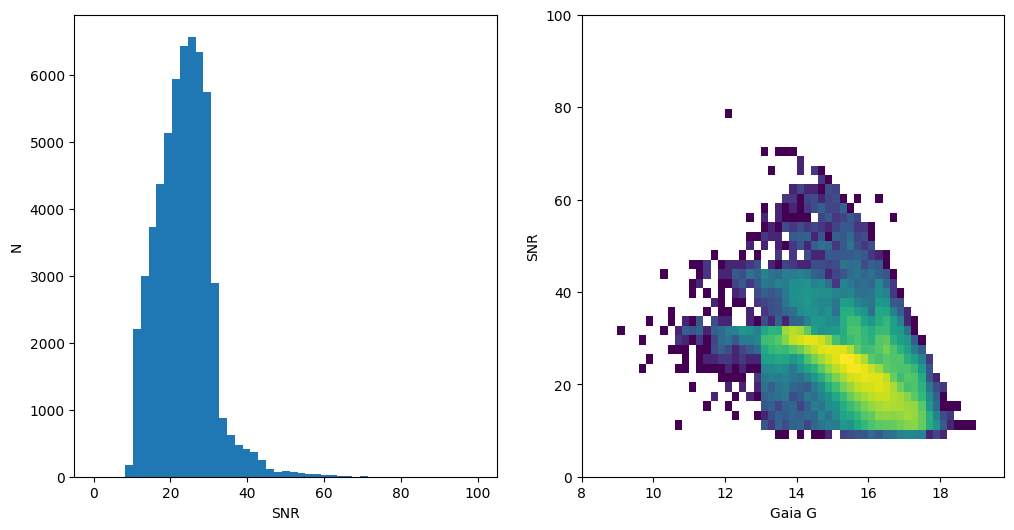

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
ax = axes[0]
ax.hist(tab["snr"], bins=np.linspace(0, 100, 50))
ax.set_xlabel("SNR")
ax.set_ylabel("N")

ax = axes[1]
hist2d_panel(ax, tab["G"], tab["snr"], bins=[np.arange(8, 20, .2), np.linspace(0, 100, 50)],
             xlabel="Gaia G", ylabel="SNR")


Kiel Diagram. You can see that we cut all stars with logg > 4.5. The Kiel diagram looks great but this is not necessarily a reflection of the data quality, we require stars to be on MIST isochrones. The temperature comes primarily from colors, and the surface gravity includes a strong prior from isochrones and parallax. This strong prior is what allows us to obtain accurate stellar parameters even though the S/N of most spectra is pretty low.

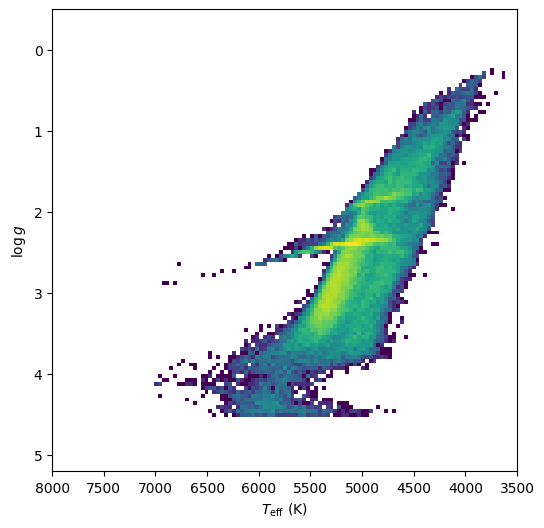

In [7]:
# Kiel Diagram
fig, ax = plt.subplots(figsize=(6, 6))
kiel_bins = [np.linspace(3500, 8000, 120), np.linspace(-0.5, 5.2, 120)]
hist2d_panel(ax, tab["Teff"], tab["logg"], bins=kiel_bins,
             xlabel=r"$T_{\rm eff}$ (K)", ylabel=r"$\log g$")
ax.invert_xaxis()
ax.invert_yaxis()

Show the trend with metallicity along the RGB. Note that this is part of the isochrone prior.

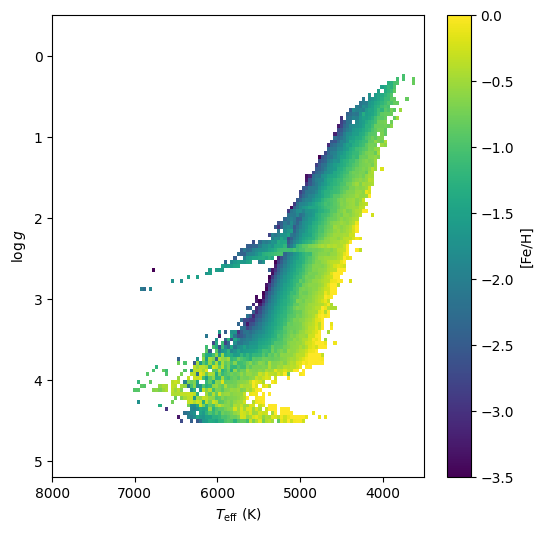

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
median_bin(ax, tab["Teff"], tab["logg"], tab["FeH"], bins_x=kiel_bins[0], bins_y=kiel_bins[1],
           xlabel=r"$T_{\rm eff}$ (K)", ylabel=r"$\log g$", cbar_label="[Fe/H]",
           vmin=-3.5, vmax=0, min_count=1);
ax.invert_xaxis()
ax.invert_yaxis()

Tinsley-Wallerstein diagram ([Fe/H] vs [alpha/Fe]).
Note that somewhere between [Fe/H] = -2 to -3, depending on the stellar parameters and signal-to-noise, MINESweeper stops being able to measure Fe and alpha independently. The total metallicity is still pretty accurate, but it mostly traces [alpha/H] through the Mg b lines.
By default we might recommend using snr > 20 if you want to use alpha abundances.

Note that MINESweeper does not have carbon as a parameter, so it can fail on highly carbon-enhanced stars that make the C2 band (see Chandra et al. 2026).

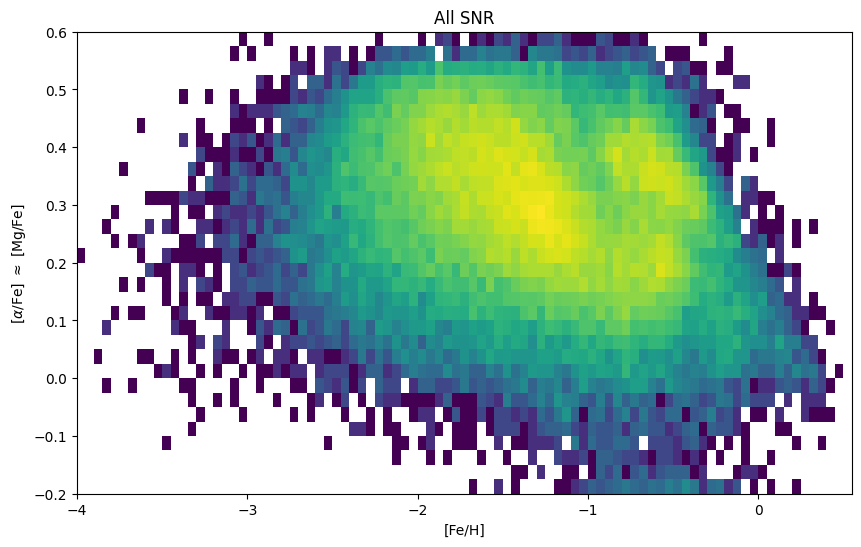

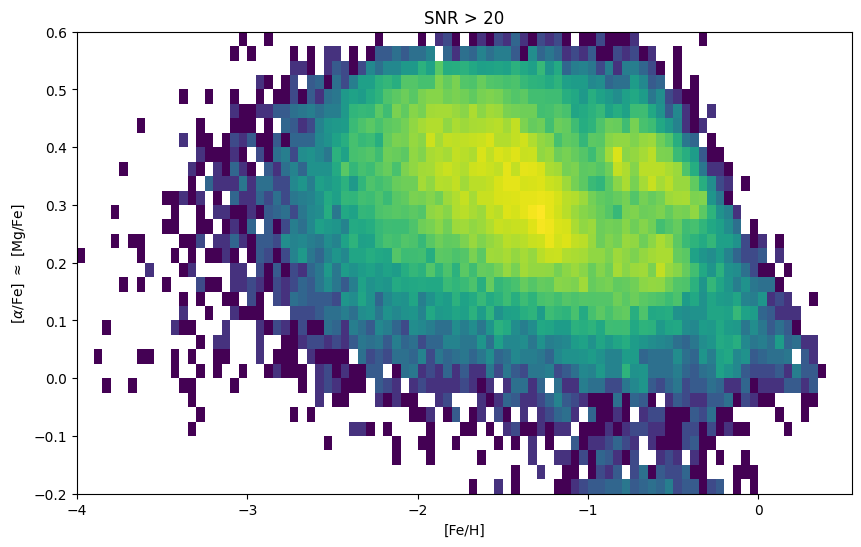

In [9]:
afe_bins = [np.arange(-4.0, 0.6, 0.05), np.arange(-0.2, 0.61, 0.025)]

fig, ax = plt.subplots(figsize=(10, 6))
hist2d_panel(ax, tab["FeH"], tab["aFe"],
             bins=afe_bins,
             xlabel="[Fe/H]", ylabel=r"[$\alpha$/Fe] $\approx$ [Mg/Fe]",
             title="All SNR")

fig, ax = plt.subplots(figsize=(10, 6))
ii = tab["snr"] > 20
hist2d_panel(ax, tab["FeH"][ii], tab["aFe"][ii],
             bins=afe_bins,
             xlabel="[Fe/H]", ylabel=r"[$\alpha$/Fe] $\approx$ [Mg/Fe]",
             title="SNR > 20")


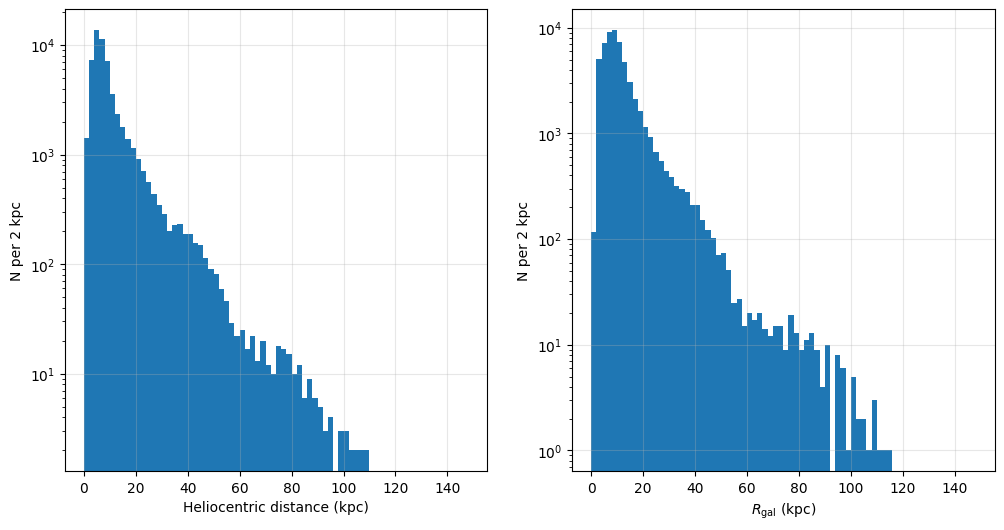

In [10]:
# Distance distribtions
dbins = np.arange(0, 150, 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
dist = np.asarray(tab["Dist"], dtype=float)
dist = dist[np.isfinite(dist) & (dist > 0)]
axes[0].hist(dist, bins=dbins, edgecolor="none")
axes[0].set_yscale("log")
axes[0].set_xlabel("Heliocentric distance (kpc)")
axes[0].set_ylabel("N per 2 kpc")
axes[0].grid(alpha=0.3)

rgal = np.asarray(tab["R_gal"], dtype=float)
rgal = rgal[np.isfinite(rgal)]
axes[1].hist(rgal, bins=dbins, edgecolor="none")
axes[1].set_yscale("log")
axes[1].set_xlabel(r"$R_{\rm gal}$ (kpc)")
axes[1].set_ylabel("N per 2 kpc")
axes[1].grid(alpha=0.3)


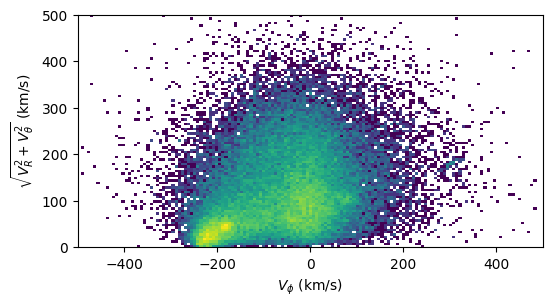

In [11]:
# Toomre diagram

toomre_bins = [np.linspace(-500, 500, 150), np.linspace(0, 500, 100)]
vperp = np.sqrt(np.asarray(tab["Vr_gal"], dtype=float) ** 2 +
                            np.asarray(tab["Vtheta_gal"], dtype=float) ** 2)
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"aspect": "equal"})

hist2d_panel(ax, tab["Vphi_gal"], vperp, bins=toomre_bins,
                         xlabel=r"$V_\phi$ (km/s)",
                         ylabel=r"$\sqrt{V_R^2+V_\theta^2}$ (km/s)")


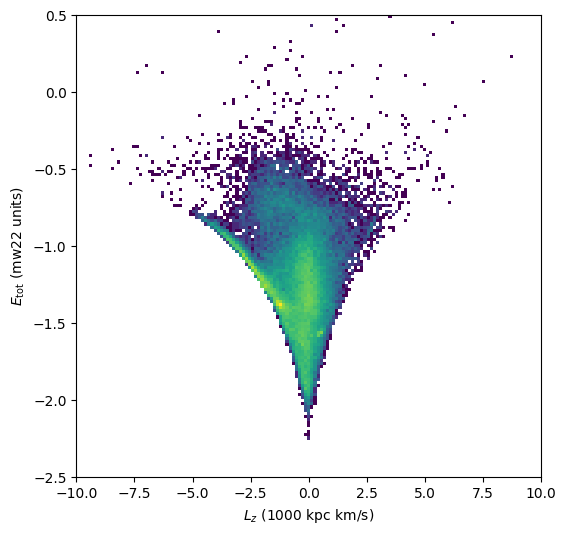

In [12]:
# Energy-angular momentum diagram
le_bins = [np.linspace(-10, 10, 150), np.linspace(-2.5, 0.5, 150)]
fig, ax = plt.subplots(figsize=(6, 6))
hist2d_panel(ax, tab["Lz"], tab["E_tot_mw22"], bins=le_bins,
                         xlabel=r"$L_z$ (1000 kpc km/s)",
                         ylabel=r"$E_{\rm tot}$ (mw22 units)",)

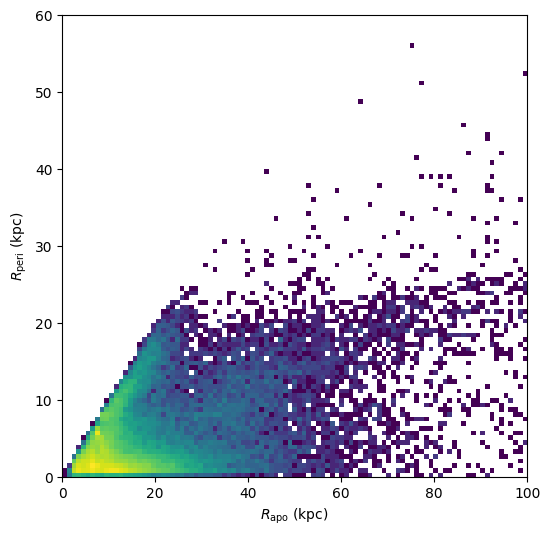

In [13]:
ap_bins = [np.linspace(0, 100, 100), np.linspace(0, 60, 100)]
fig, ax = plt.subplots(figsize=(6, 6))
hist2d_panel(ax, tab["R_apo_mw22"], tab["R_peri_mw22"], bins=ap_bins,
                         xlabel=r"$R_{\rm apo}$ (kpc)", ylabel=r"$R_{\rm peri}$ (kpc)",
                         )


### About this notebook

This notebook was created to explore the MINESweeper VAC.

**Authors**: Alex Ji (UChicago)

**Last Update**: 2026 Sep 23

If you use `astropy`  for published research, please cite the
authors. Follow this link for more information about citing `astropy`:

* [Citing `astropy`](https://www.astropy.org/acknowledging.html)

And of course please [cite](https://sdss.org/collaboration/citing-sdss/) SDSS when you use our data.